# Eric Rumsfeld's Quick Random Forest Algorithm to Predict the March Madness 2026 Bracket
### Date: March 18th, 2026

##### In this notebook, I take historic NCAA Men's D1 regular season and March Madness data, and create a random forest algorithm to predict the outcome of each game in The Big Dance this year. This code takes two files as inputs: DEV _ March Madness.csv from (https://www.kaggle.com/datasets/jonathanpilafas/2024-march-madness-statistical-analysis?resource=download) and Tournament Matchups.csv from (https://www.kaggle.com/datasets/nishaanamin/march-madness-data). 

##### I return the most likely winner of 31 of the 32 first round matchups (LIU was missing from the first dataset) as well as each subsequent matchup in the tournament. Pre-testing the validity of my results, this algorithm has a ~74% historic success rate with a low log-loss value of 0.53, indicating high accuracy. 

##### In total, the basic version of this project took about 10 hours to complete from idea drafting, to data acquisition, data management, analysis, and reporting. I thoroughly enjoyed this brief project and I hope you get something out of it too! Please contact: erumsfel[at]uci.edu if you'd like to discuss it further.

# Notebook Outline
#### Section 1: Data Loading
#### Section 2: 

## Section 1: Loading Python Packages and the Data

### 1a) Imports, reading in the data

In [294]:
# Making imports
import pandas as pd
import numpy as np
from rapidfuzz import process
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import plot_tree
import time

In [295]:
# Loading in CSVs
df = pd.read_csv("./archive/DEV _ March Madness.csv") # From Jonathan Pilafas's Kaggle Dataset: March Madness Historical DataSet (2002 to 2026). Obtained 3/17/26.

df_mmresults = pd.read_csv("./amin_archive/Tournament Matchups.csv") # From Nishaan Amin's Kaggle Dataset: March Madness Data. Obtained 3/17/26.


### 1b) Reading in the data, initial data management

In [296]:
# Working first with DEV by loading it
#df.head()

# Truncating the dataset to only having seasons 2008-26. This temporal range matches that of the other dataset.
df1 = df[df['Season']>=2008]

# Truncating the dataset to only have the columns I care about
df2 = df1[['Season', 'Mapped ESPN Team Name', 'Adjusted Offensive Efficiency', 'Adjusted Defensive Efficiency', 'AdjTempo', 'FG2Pct', 
           'FG3Pct', 'FTPct', 'BlockPct', 'StlRate', 'FG3Rate',  'OppFG2Pct', 'OppFG3Pct', 'OppBlockPct', 'OppStlRate', 
           'OppFG3Rate',  'Experience', 'Bench', 'Active Coaching Length Index', 'Seed', 'Top 12 in AP Top 25 During Week 6?', 
           'ORPct', 'Post-Season Tournament']]
# Renaming Mapped ESPN Team Name --> TEAM
df2.rename(columns={'Mapped ESPN Team Name': 'TEAM'}, inplace=True)

# don't worry about the error below this box

/var/folders/z0/y1tjyntj46b_6q22ng6c1nfm0000gn/T/ipykernel_38377/2135110006.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.rename(columns={'Mapped ESPN Team Name': 'TEAM'}, inplace=True)


In [297]:
# Only keeping rows in df2 where 'Post-Season Tournament' == 'March Madness'

df2 = df2[df2['Post-Season Tournament'] == 'March Madness']
#print(df2)

In [298]:
# Working with the other dataset: Tournament Matchups 

df3 = df_mmresults[df_mmresults['YEAR']<2026]
df3.rename(columns={'YEAR': 'Season'}, inplace=True)

#print(df3)
# don't worry about the error below this box

/var/folders/z0/y1tjyntj46b_6q22ng6c1nfm0000gn/T/ipykernel_38377/179870741.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3.rename(columns={'YEAR': 'Season'}, inplace=True)


##### 1c) Mapping team names so the two datasets can be merged

In [299]:
# Handling mapping team name issue I: making sure the team names aren't too chopped
df3["TEAM"] = df3["TEAM"].str.strip()
df2["TEAM"] = df2["TEAM"].str.strip()
# don't worry about the error below this box

/var/folders/z0/y1tjyntj46b_6q22ng6c1nfm0000gn/T/ipykernel_38377/3564912218.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["TEAM"] = df3["TEAM"].str.strip()


In [300]:
# Handling mapping team name issue II: matching team names between the datasets

# Extracting unique names
teams_df3 = set(df3["TEAM"].unique())
teams_df2 = set(df2["TEAM"].unique())

# Auto-match obvious ones
mapping = {}

for t in teams_df3:
    if t in teams_df2:
        mapping[t] = t

In [301]:
# Handling mapping team name issue III: matching team names between the datasets pt. 2

unmatched = [t for t in teams_df3 if t not in mapping]

for team in unmatched:
    match, score, _ = process.extractOne(team, teams_df2)
    
    if score > 95:  # high confidence
        mapping[team] = match
    else:
        mapping[team] = None  # flag for manual fix

In [302]:
# Handling mapping team name issue IV: listing the troubled children
{k: v for k, v in mapping.items() if v is None}

{'San Diego St.': None,
 'North Carolina St.': None,
 'Texas A&M Corpus Chris': None,
 'Louisiana Lafayette': None,
 'Kent St.': None,
 'Penn': None,
 'Grambling St.': None,
 'Norfolk St.': None,
 'Jacksonville St.': None,
 'Morehead St.': None,
 'Iowa St.': None,
 'Montana St.': None,
 'Georgia St.': None,
 'LIU Brooklyn': None,
 'North Dakota St.': None,
 'Oklahoma St.': None,
 'Cal St. Northridge': None,
 'Kansas St.': None,
 'Albany': None,
 'Mississippi St.': None,
 'Alabama St.': None,
 'Michigan St.': None,
 'Boise St.': None,
 'Wright St.': None,
 'Arkansas Pine Bluff': None,
 'East Tennessee St.': None,
 'Sam Houston St.': None,
 'Florida St.': None,
 'Mississippi': None,
 'Ohio St.': None,
 'Loyola MD': None,
 'Utah St.': None,
 'Nebraska Omaha': None,
 'Morgan St.': None,
 'Long Beach St.': None,
 'Indiana St.': None,
 'Washington St.': None,
 'Fresno St.': None,
 'Kennesaw St.': None,
 'Cal St. Bakersfield': None,
 'Portland St.': None,
 'American': None,
 'Detroit': None,


In [303]:
# Handling mapping team name issue V: correcting the troubled ones
mapping.update({
    'McNeese State': "McNeese",
    "	McNeese State": "McNeese",
    "San Diego": "San Diego",
    "	Washington": "Washington",
    "	San Diego": "San Diego",
    "New Mexico": "New Mexico",
    "North Dakota": "North Dakota",
    'Jacksonville St.': 'Jacksonville State',
    'South Dakota St.': 'South Dakota State',
    'East Tennessee St.': 'East Tennessee State',
    'Connecticut': 'UConn',
    'LIU Brooklyn': 'LIU',
    'Morehead St.': 'Morehead State',
    'Michigan St.': 'Michigan State',
    'Nebraska Omaha': 'Omaha',
    'Miami FL': 'Miami',
    'Cleveland St.': 'Cleveland State',
    'Florida St.': 'Florida State',
    'Loyola MD': 'Loyola Maryland',
    'Penn St.': 'Penn State',
    'Morgan St.': 'Morgan State',
    'Oklahoma St.': 'Oklahoma State',
    'Cal St. Bakersfield': 'CSU Bakersfield',
    'Cal St. Fullerton': 'CSU Fullerton',
    'Iowa St.': 'Iowa State',
    'Portland St.': 'Portland State',
    'Alabama St.': 'Alabama State',
    'Murray St.': 'Murray State',
    'Ohio St.': 'Ohio State',
    'Indiana St.': 'Indiana State',
    'Kansas St.': 'Kansas State',
    'American': 'American Univ',
    'Fresno St.': 'Fresno State',
    'Montana St.': 'Montana State',
    'Oregon St.': 'Oregon State',
    'Kent St.': 'Kent State',
    'Georgia St.': 'Georgia State',
    'College of Charleston': 'Charleston',
    'Mississippi St.': 'Mississippi State',
    'Wichita St.': 'Wichita State',
    'Wright St.': 'Wright State',
    'Mississippi': 'Ole Miss',
    'Weber St.': 'Weber State',
    'Cal St. Northridge': 'CSUN',
    'Norfolk St.': 'Norfolk State',
    'Colorado St.': 'Colorado State',
    'Penn': 'Pennsylvania',
    'Utah St.': 'Utah State',
    'Louisiana Lafayette': 'Louisiana',
    'Detroit': 'Detroit Mercy',
    'McNeese St.': 'McNeese',
    'Long Beach St.': 'Long Beach State',
    'Kennesaw St.': 'Kennesaw State',
    'Arizona St.': 'Arizona State',
    'Boise St.': 'Boise State',
    'Grambling St.': 'Grambling State',
    'Texas A&M Corpus Chris': 'Texas A&M-Corpus Christi',
    'North Dakota St.': 'North Dakota State',
    'Sam Houston St.': 'Sam Houston State',
    'Mississippi Valley St.': 'Mississippi Valley State',
    'San Diego St.': 'San Diego State',
    'Northwestern St.': 'Northwestern State',
    'Washington St.': 'Washington State',
    'North Carolina St.': 'NC State',
    'North Carolina State': 'NC State',
    'Gardner Webb': 'Gardner-Webb',
    'Arkansas Pine Bluff': 'Arkansas-Pine Bluff',
    'Albany': 'UAlbany',
    'New Mexico St.': 'New Mexico State',
    'Grambling State': 'Grambling',
    'CSU Fullerton': 'Cal State Fullerton',
    'CSU Bakersfield': 'Cal State Bakersfield',
    'American Univ': 'American University',
    'LIU': 'Long Island University',
    'Sam Houston State': 'Sam Houston'
})

In [304]:
# Handling mapping team name issue VI: performing the map of team names on Tournament Matchups so it has a column that correlates to DEV
df3.loc[:, "team_mapped"] = df3["TEAM"].map(mapping)
df3["team_mapped"].isna().sum()
# ^ This should print a '0' if the mapping went well

/var/folders/z0/y1tjyntj46b_6q22ng6c1nfm0000gn/T/ipykernel_38377/2131732861.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3.loc[:, "team_mapped"] = df3["TEAM"].map(mapping)


0

### 1c) Creating and managing the historical MM Matchups dataset

In [305]:
# Creating the former MM matchups dataset (df_games): Every March Madness game 2008-2025, the final score, and who won
games = []

for i in range(0, len(df3), 2):
    teamA = df3.iloc[i]
    teamB = df3.iloc[i+1]
    
    games.append({
        "Season": teamA["Season"],
        
        "TeamA": teamA["team_mapped"],
        "TeamB": teamB["team_mapped"],
        
        "ScoreA": teamA["SCORE"],
        "ScoreB": teamB["SCORE"],
        
        "TeamA_Win": 1 if teamA["SCORE"] > teamB["SCORE"] else 0
    })

df_games = pd.DataFrame(games)
#print(df_games)

In [306]:
# Merging Team A Features to the matchups dataset
df_games = df_games.merge(
    df2,
    left_on=["Season", "TeamA"],
    right_on=["Season", "TEAM"],
    how="left"
)

In [307]:
# Merging Team B Features to the matchups dataset
df2_B = df2.copy().add_suffix("_B")

df_games = df_games.merge(
    df2_B,
    left_on=["Season", "TeamB"],
    right_on=["Season_B", "TEAM_B"],
    how="left"
)

In [308]:
# Sanity check: Ideally if the merging went perfect, then everything this prints is a 0, but that's not the case so there's more work to do
#df_games.isna().sum()

In [309]:
# Dropping the unnecessary things I don't actually want-- a few columns I later decided weren't as important, and just deleting all missing data

df_games = df_games.drop(columns=[
    "TEAM", "TEAM_B", "Season_B",
    "Post-Season Tournament", "Post-Season Tournament_B"
], errors="ignore")

df_games = df_games.dropna()

In [310]:
# Now the verification from before is good!
#df_games.isna().sum()

In [311]:
# Recasting seed data type
df_games['Seed'] = df_games['Seed'].astype('int64')
df_games['Seed_B'] = df_games['Seed_B'].astype('int64')

### 1d) Defining features, feature differences, last data cleanup

In [312]:
# Defining feature columns
feature_cols = ['Adjusted Offensive Efficiency', 'Adjusted Defensive Efficiency', 'AdjTempo', 'FG2Pct', 
           'FG3Pct', 'FTPct', 'BlockPct', 'StlRate', 'FG3Rate',  'OppFG2Pct', 'OppFG3Pct', 'OppBlockPct', 'OppStlRate', 
           'OppFG3Rate',  'Experience', 'Bench', 'Active Coaching Length Index', 'Seed', 
           'ORPct']

In [313]:
# Creating Feature Differences-- this is my most key, unique step for my model approach! 
## I am choosing to say, I don't care too much about what overall adjusted offensive efficiency your team has, more about how yours stacks up to your opponents.
df_games["Adjusted Offensive Efficiency_diff"] = df_games["Adjusted Offensive Efficiency"] - df_games["Adjusted Offensive Efficiency_B"]
df_games["Adjusted Defensive Efficiency_diff"] = df_games["Adjusted Defensive Efficiency"] - df_games["Adjusted Defensive Efficiency_B"]
df_games["AdjTempo_diff"] = df_games["AdjTempo"] - df_games["AdjTempo_B"]
df_games["FG2Pct_diff"] = df_games["FG2Pct"] - df_games["FG2Pct_B"]
df_games["FG3Pct_diff"] = df_games["FG3Pct"] - df_games["FG3Pct_B"]
df_games["FTPct_diff"] = df_games["FTPct"] - df_games["FTPct_B"]
df_games["BlockPct_diff"] = df_games["BlockPct"] - df_games["BlockPct_B"]
df_games["StlRate_diff"] = df_games["StlRate"] - df_games["StlRate_B"]
df_games["FG3Rate_diff"] = df_games["FG3Rate"] - df_games["FG3Rate_B"]
df_games["OppFG2Pct_diff"] = df_games["OppFG2Pct"] - df_games["OppFG2Pct_B"]
df_games["OppFG3Pct_diff"] = df_games["OppFG3Pct"] - df_games["OppFG3Pct_B"]
df_games["OppBlockPct_diff"] = df_games["OppBlockPct"] - df_games["OppBlockPct_B"]
df_games["OppStlRate_diff"] = df_games["OppStlRate"] - df_games["OppStlRate_B"]
df_games["OppFG3Rate_diff"] = df_games["OppFG3Rate"] - df_games["OppFG3Rate_B"]
df_games["Experience_diff"] = df_games["Experience"] - df_games["Experience_B"]
df_games["Bench_diff"] = df_games["Bench"] - df_games["Bench_B"]
df_games["Active Coaching Length Index_diff"] = df_games["Active Coaching Length Index"] - df_games["Active Coaching Length Index_B"]
df_games["ORPct_diff"] = df_games["ORPct"] - df_games["ORPct_B"]
df_games["Seed_diff"] = df_games["Seed"] - df_games["Seed_B"]
#df_games["T12_diff"] = df_games["Top 12 in AP Top 25 During Week 6?"] - df_games["Top 12 in AP Top 25 During Week 6?_B"]

In [314]:
# Recasting all numeric columns from strings to numpys

for bap in df_games:
    try:
        df_games[bap] = df_games[bap].astype(float)
    except:
        print()
        #print(bap,' couldn\'t be converted to a float')

for beep in df2:
    try:
        df2[beep] = df2[beep].astype(float)
    except:
        print()
        #print(beep,' couldn\'t be converted to a float')
# There's a space here, that's fine

In [315]:
# If you wanted to check out my data columns
#print(df_games.columns)

## Section 2: Creating the Random Forest Algorithm Model

### 2a) Prepping the final dataset

In [316]:
# Dropping raw columns for simplicity. Again, I only care about how the teams matched up with each other, not their objective stats.
X_cols = [col for col in df_games.columns if "_diff" in col]
X = df_games[X_cols]
y = df_games["TeamA_Win"]

In [317]:
# Doubling the dataset! This step is very important for removing bias in the data (so the model doesn't learn that teams which come first are more likely to win just because they were listed first)
df_rev = df_games.copy()

# flip outcome
df_rev["TeamA_Win"] = 1 - df_games["TeamA_Win"]

# flip feature differences
for col in X_cols:
    df_rev[col] = -df_games[col]

df_final = pd.concat([df_games, df_rev], ignore_index=True)

### 2b) Training the model

In [339]:
# Training the model-- this is where the magic happens!
start_time = time.perf_counter()

#model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42) # <-- This was my first go, it was fine.
model = RandomForestClassifier(n_estimators=500,
                               max_depth=10,
                               min_samples_split=10,
                               random_state=42) # <-- This is my second one I made before MM26 started
#model = RandomForestClassifier(n_estimators=1000,max_depth=10,min_samples_split=10,max_features=0.7, min_samples_leaf=4,random_state=42) # <-- This is the third model I made after MM26, with hyperparameter tuning added in

model.fit(X, y)


end_time = time.perf_counter()

elapsed_time = end_time - start_time
print(f"The model was created in {elapsed_time:0.4f} seconds") # about 0.83 seconds on my macbook pro

The model was created in 0.9435 seconds


### 2c) Creating the matchup function, and 2026 MM Bracket

In [340]:
# Creating the matchup function. This runs the teams's stats through the model, and has the model predict each team's chance of winning, as well as declaring who will win the matchup.

def predict_matchup(teamA, teamB, df2, model):
    if teamA not in set(df2["TEAM"]):
        raise ValueError(f"{teamA} not found in df2")
    if teamB not in set(df2["TEAM"]):
        raise ValueError(f"{teamB} not found in df2")
    
    teamA_stats = df2[df2["TEAM"] == teamA].iloc[0]
    teamB_stats = df2[df2["TEAM"] == teamB].iloc[0]
    
    features = []
    for col in feature_cols:
        #print('Col:',col,' Type:', type(col))
        diff = teamA_stats[col] - teamB_stats[col]
        features.append(diff)
    
    prob = model.predict_proba([features])[0][1]  # P(TeamA wins)
    
    return {
        "TeamA": teamA,
        "TeamB": teamB,
        "TeamA_win_prob": prob,
        "TeamB_win_prob": 1 - prob,
        "Winner": teamA if prob > 0.5 else teamB
    }

In [341]:
# Inputting the 2026 Bracket Matchups! The First Round is initialized here.

round64 = [
    ("Duke", "Siena"),
    ("Ohio State", "TCU"),
    ("St. John's", "Northern Iowa"),
    ("Kansas", "California Baptist"),
    ("Louisville", "South Florida"),
    ("Michigan State", "North Dakota State"),
    ("UCLA", "UCF"),
    ("UConn", "Furman"),
    ("Florida", "Lehigh"),
    ("Clemson", "Iowa"),
    ("Vanderbilt", "McNeese"),
    ("Nebraska", "Troy"),
    ("North Carolina", "VCU"),
    ("Illinois", "Pennsylvania"),
    ("Saint Mary's", "Texas A&M"),
    ("Houston", "Idaho"),
    #("Arizona", "Long Island University"),# DEV does not contain Long Island University's data, so in the interest of time I will just assume Arizona will win this game.
    ("Villanova", "Utah State"),
    ("Wisconsin", "High Point"),
    ("Arkansas", "Hawaii"),
    ("BYU", "Texas"),
    ("Gonzaga", "Kennesaw State"),
    ("Miami", "Missouri"),
    ("Purdue", "Queens University"),
    ("Michigan", "Howard"),
    ("Georgia", "Saint Louis"),
    ("Texas Tech", "Akron"),
    ("Alabama", "Hofstra"),
    ("Tennessee", "Miami (OH)"),
    ("Virginia", "Wright State"),
    ("Kentucky", "Santa Clara"),
    ("Iowa State", "Tennessee State")
]

In [342]:
# Creating this year's matchup dataset
df2_2026 = df2[df2["Season"] == 2026]

In [343]:
# Defining Bracket
def run_round(matchups):
    results = []
    
    for teamA, teamB in matchups:
        pred = predict_matchup(teamA, teamB, df2_2026, model)
        results.append(pred)
    
    return results

## Section 3: Running the Results

### 3a) Round of 64 results

In [344]:
# Running the thing!!
r64_results = run_round(round64)
# There are a bunch of warnings, but that's fine

/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted w

In [345]:
print('FINAL ROUND 1 RESULTS:\n\n')
for game in r64_results:
    print(f"{game['TeamA']} vs {game['TeamB']}: "
          f"{game['TeamA']} {game['TeamA_win_prob']:.2%} | "
          f"{game['TeamB']} {game['TeamB_win_prob']:.2%} → "
          f"{game['Winner']}")
print('\n')

FINAL ROUND 1 RESULTS:


Duke vs Siena: Duke 68.14% | Siena 31.86% → Duke
Ohio State vs TCU: Ohio State 56.11% | TCU 43.89% → Ohio State
St. John's vs Northern Iowa: St. John's 62.40% | Northern Iowa 37.60% → St. John's
Kansas vs California Baptist: Kansas 84.53% | California Baptist 15.47% → Kansas
Louisville vs South Florida: Louisville 62.67% | South Florida 37.33% → Louisville
Michigan State vs North Dakota State: Michigan State 72.78% | North Dakota State 27.22% → Michigan State
UCLA vs UCF: UCLA 79.53% | UCF 20.47% → UCLA
UConn vs Furman: UConn 72.84% | Furman 27.16% → UConn
Florida vs Lehigh: Florida 73.11% | Lehigh 26.89% → Florida
Clemson vs Iowa: Clemson 32.61% | Iowa 67.39% → Iowa
Vanderbilt vs McNeese: Vanderbilt 76.18% | McNeese 23.82% → Vanderbilt
Nebraska vs Troy: Nebraska 81.46% | Troy 18.54% → Nebraska
North Carolina vs VCU: North Carolina 42.59% | VCU 57.41% → VCU
Illinois vs Pennsylvania: Illinois 65.31% | Pennsylvania 34.69% → Illinois
Saint Mary's vs Texas A&M: Sai

In [327]:
# If you wanted to take a more in-depth look at the results
#print(r64_results)

In [328]:
# Printing the results again, this time ordered by the model's confidence that the higher seeded team wins
yahoo = pd.DataFrame(r64_results, columns=["TeamA", "TeamB", "TeamA_win_prob", "TeamB_win_prob", "Winner"])
yahoo_sorted_desc = yahoo.sort_values(by='TeamA_win_prob', ascending=False)
print(yahoo_sorted_desc)

             TeamA               TeamB  TeamA_win_prob  TeamB_win_prob  \
17       Wisconsin          High Point        0.865770        0.134230   
3           Kansas  California Baptist        0.864645        0.135355   
6             UCLA                 UCF        0.827417        0.172583   
11        Nebraska                Troy        0.824251        0.175749   
5   Michigan State  North Dakota State        0.816742        0.183258   
22          Purdue   Queens University        0.815622        0.184378   
15         Houston               Idaho        0.810981        0.189019   
20         Gonzaga      Kennesaw State        0.804964        0.195036   
21           Miami            Missouri        0.803752        0.196248   
7            UConn              Furman        0.803040        0.196960   
0             Duke               Siena        0.797604        0.202396   
10      Vanderbilt             McNeese        0.796586        0.203414   
8          Florida              Lehigh

### 3b) Round of 32 results

In [346]:
# Inputting the Second Round Here. Although I could code this more elegantly, I am doing it by hand so it's easier for you to play with and alter in extra options later.

round32 = [
    ("Duke", "Ohio State"),# TCU
    ("St. John's", "Kansas"),
    ("Louisville", "Michigan State"),
    ("UCLA", "UConn"),
    ("Florida", "Iowa"),
    ("Vanderbilt", "Nebraska"),
    ("Illinois", "VCU"),
    ("Saint Mary's", "Houston"),# Texas A&M
    ("Arizona", "Utah State"),
    ("Wisconsin", "Arkansas"),# High Point
    ("BYU", "Gonzaga"),# Texas
    ("Miami", "Purdue"),
    ("Michigan", "Saint Louis"),
    ("Texas Tech", "Alabama"),
    ("Tennessee", "Virginia"),
    ("Kentucky", "Iowa State")
]

In [347]:
# Running the round of 32 results

r32_results = run_round(round32)


print('FINAL ROUND OF 32 RESULTS:\n\n')
for game in r32_results:
    print(f"{game['TeamA']} vs {game['TeamB']}: "
          f"{game['TeamA']} {game['TeamA_win_prob']:.2%} | "
          f"{game['TeamB']} {game['TeamB_win_prob']:.2%} → "
          f"{game['Winner']}")
print('\n')
# There are a bunch of warnings, but that's fine

FINAL ROUND OF 32 RESULTS:


Duke vs Ohio State: Duke 68.89% | Ohio State 31.11% → Duke
St. John's vs Kansas: St. John's 40.08% | Kansas 59.92% → Kansas
Louisville vs Michigan State: Louisville 45.78% | Michigan State 54.22% → Michigan State
UCLA vs UConn: UCLA 49.32% | UConn 50.68% → UConn
Florida vs Iowa: Florida 61.58% | Iowa 38.42% → Florida
Vanderbilt vs Nebraska: Vanderbilt 48.12% | Nebraska 51.88% → Nebraska
Illinois vs VCU: Illinois 71.90% | VCU 28.10% → Illinois
Saint Mary's vs Houston: Saint Mary's 24.84% | Houston 75.16% → Houston
Arizona vs Utah State: Arizona 73.18% | Utah State 26.82% → Arizona
Wisconsin vs Arkansas: Wisconsin 38.04% | Arkansas 61.96% → Arkansas
BYU vs Gonzaga: BYU 52.16% | Gonzaga 47.84% → BYU
Miami vs Purdue: Miami 24.24% | Purdue 75.76% → Purdue
Michigan vs Saint Louis: Michigan 72.54% | Saint Louis 27.46% → Michigan
Texas Tech vs Alabama: Texas Tech 47.78% | Alabama 52.22% → Alabama
Tennessee vs Virginia: Tennessee 40.79% | Virginia 59.21% → Virginia


/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted w

### 3c) Round of 16

In [350]:
# Inputting the Sweet 16 Here. Although I could code this more elegantly, I am doing it by hand so it's easier for you to play with and alter in extra options later.

round16 = [
    ("Duke", "Kansas"),# St. John's
    ("UConn", "Michigan State"),
    ("Florida", "Vanderbilt"),# Nebraska
    ("Illinois", "Houston"),
    ("Arizona", "Arkansas"),
    ("BYU", "Purdue"),# Texas
    ("Michigan", "Alabama"),
    ("Iowa State", "Virginia")# Tennessee
]

In [351]:
# Running the Sweet 16 results

r16_results = run_round(round16)


print('FINAL SWEET 16 RESULTS:\n\n')
for game in r16_results:
    print(f"{game['TeamA']} vs {game['TeamB']}: "
          f"{game['TeamA']} {game['TeamA_win_prob']:.2%} | "
          f"{game['TeamB']} {game['TeamB_win_prob']:.2%} → "
          f"{game['Winner']}")
print('\n')
# There are a bunch of warnings, but that's fine

FINAL SWEET 16 RESULTS:


Duke vs Kansas: Duke 65.22% | Kansas 34.78% → Duke
UConn vs Michigan State: UConn 52.02% | Michigan State 47.98% → UConn
Florida vs Vanderbilt: Florida 56.15% | Vanderbilt 43.85% → Florida
Illinois vs Houston: Illinois 45.70% | Houston 54.30% → Houston
Arizona vs Arkansas: Arizona 61.49% | Arkansas 38.51% → Arizona
BYU vs Purdue: BYU 25.88% | Purdue 74.12% → Purdue
Michigan vs Alabama: Michigan 64.91% | Alabama 35.09% → Michigan
Iowa State vs Virginia: Iowa State 68.24% | Virginia 31.76% → Iowa State




/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted w

### 3d) Round of 8

In [352]:
# Inputting the Elite 8 Here. Although I could code this more elegantly, I am doing it by hand so it's easier for you to play with and alter in extra options later.

round8 = [
    ("Duke", "UConn"),
    ("Florida", "Illinois"),# Iowa 
    ("Arizona", "Purdue"),
    ("Michigan", "Iowa State")# Tennessee
]

In [353]:
# Running the Elite 8 results

r8_results = run_round(round8)


print('FINAL ELITE 8 RESULTS:\n\n')
for game in r8_results:
    print(f"{game['TeamA']} vs {game['TeamB']}: "
          f"{game['TeamA']} {game['TeamA_win_prob']:.2%} | "
          f"{game['TeamB']} {game['TeamB_win_prob']:.2%} → "
          f"{game['Winner']}")
print('\n')
# There are a bunch of warnings, but that's fine

FINAL ELITE 8 RESULTS:


Duke vs UConn: Duke 70.85% | UConn 29.15% → Duke
Florida vs Illinois: Florida 38.52% | Illinois 61.48% → Illinois
Arizona vs Purdue: Arizona 56.81% | Purdue 43.19% → Arizona
Michigan vs Iowa State: Michigan 59.06% | Iowa State 40.94% → Michigan




/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### 3e) Semi-finals

In [354]:
# Inputting the Final 4 Here. Although I could code this more elegantly, I am doing it by hand so it's easier for you to play with and alter in extra options later.

round4 = [
    ("Duke", "Illinois"),# UConn 
    ("Arizona", "Michigan")
]

In [355]:
# Running the Final 4 results

r4_results = run_round(round4)


print('FINAL ELITE 4 RESULTS:\n\n')
for game in r4_results:
    print(f"{game['TeamA']} vs {game['TeamB']}: "
          f"{game['TeamA']} {game['TeamA_win_prob']:.2%} | "
          f"{game['TeamB']} {game['TeamB_win_prob']:.2%} → "
          f"{game['Winner']}")
print('\n')
# There are a bunch of warnings, but that's fine

FINAL ELITE 4 RESULTS:


Duke vs Illinois: Duke 55.44% | Illinois 44.56% → Duke
Arizona vs Michigan: Arizona 45.46% | Michigan 54.54% → Michigan




/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### 3f) Championship

In [356]:
# Inputting the Championship Game Here. Although I could code this more elegantly, I am doing it by hand so it's easier for you to play with and alter in extra options later.

round_final = [
    ("Duke", "Michigan")# UConn 
]

In [357]:
# Running the Championship results

rfinal_results = run_round(round_final)


print('FINAL CHAMPIONSHIP RESULTS:\n\n')
for game in rfinal_results:
    print(f"{game['TeamA']} vs {game['TeamB']}: "
          f"{game['TeamA']} {game['TeamA_win_prob']:.2%} | "
          f"{game['TeamB']} {game['TeamB_win_prob']:.2%} → "
          f"{game['Winner']}")
print('\n')
# There are a bunch of warnings, but that's fine

FINAL CHAMPIONSHIP RESULTS:


Duke vs Michigan: Duke 48.54% | Michigan 51.46% → Michigan




/Users/ericrumsfeld/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### There you have it! According to analytics, and my Random Forest Algorithm, the 2026 March Madness Men's Tournament champion is:
# Michigan Wolverines

## Section 4: Breaking Down the Predictions

In [358]:
# Breaking down the predictions a little bit. Just rephrasing the same information in an easily ingestible way.

def print_group(title, df, team_col, prob_col, opp_col):
    print(title)
    
    if df.empty:
        print("None else from this side")
        return
    
    for _, row in df.iterrows():
        team = row[team_col]
        opp = row[opp_col]
        prob = row[prob_col] * 100
        
        print(f"{team} {prob:.2f}% (vs {opp})")


# Locks (≥ 80%)
locks1 = yahoo[yahoo["TeamA_win_prob"] >= 0.80]
locks2 = yahoo[yahoo["TeamB_win_prob"] >= 0.80]

print_group(
    "The following matchup results are locks:",
    locks1, "TeamA", "TeamA_win_prob", "TeamB"
)
print_group(
    "",
    locks2, "TeamB", "TeamB_win_prob", "TeamA"
)


# Lean (60–80%)
lean1 = yahoo[(yahoo["TeamA_win_prob"] >= 0.60) & (yahoo["TeamA_win_prob"] < 0.80)]
lean2 = yahoo[(yahoo["TeamB_win_prob"] >= 0.60) & (yahoo["TeamB_win_prob"] < 0.80)]

print("\n\nYou should likely lean to my favorite for:")
print_group("", lean1, "TeamA", "TeamA_win_prob", "TeamB")
print_group("", lean2, "TeamB", "TeamB_win_prob", "TeamA")


# Upset range (50–60%)
ups1 = yahoo[(yahoo["TeamA_win_prob"] >= 0.50) & (yahoo["TeamA_win_prob"] < 0.60)]
ups2 = yahoo[(yahoo["TeamB_win_prob"] >= 0.50) & (yahoo["TeamB_win_prob"] < 0.60)]

print("\n\nI'm not as confident in these, so you may find some opportunities going against what I say in:")
print_group("", ups1, "TeamA", "TeamA_win_prob", "TeamB")
print_group("", ups2, "TeamB", "TeamB_win_prob", "TeamA")

The following matchup results are locks:
Kansas 86.46% (vs California Baptist)
Michigan State 81.67% (vs North Dakota State)
UCLA 82.74% (vs UCF)
UConn 80.30% (vs Furman)
Nebraska 82.43% (vs Troy)
Houston 81.10% (vs Idaho)
Wisconsin 86.58% (vs High Point)
Gonzaga 80.50% (vs Kennesaw State)
Miami 80.38% (vs Missouri)
Purdue 81.56% (vs Queens University)

None else from this side


You should likely lean to my favorite for:

Duke 79.76% (vs Siena)
St. John's 76.89% (vs Northern Iowa)
Louisville 62.87% (vs South Florida)
Florida 79.05% (vs Lehigh)
Vanderbilt 79.66% (vs McNeese)
Illinois 71.60% (vs Pennsylvania)
Saint Mary's 67.63% (vs Texas A&M)
Arkansas 78.27% (vs Hawaii)
BYU 74.00% (vs Texas)
Michigan 77.84% (vs Howard)
Texas Tech 73.09% (vs Akron)
Alabama 69.79% (vs Hofstra)
Tennessee 79.01% (vs Miami (OH))
Virginia 77.30% (vs Wright State)
Iowa State 77.69% (vs Tennessee State)

Iowa 71.48% (vs Clemson)
Utah State 69.27% (vs Villanova)


I'm not as confident in these, so you may find 

## Section 5: Verifying this Model can be Trusted

In [359]:
# Checking raw accuracy
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

model.fit(X_train, y_train)
preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))

# Output is 73.9% which is very good for March Madness! Anything 60-75% would have been great

Accuracy: 0.7393364928909952


In [360]:
# Checking probability quality
from sklearn.metrics import log_loss

probs = model.predict_proba(X_test)[:,1]
print("Log Loss:", log_loss(y_test, probs))

# Output is 0.53 which is very low and therefore very good! A value like 0.60-0.68 is good whereas 0.75 would not have been good

Log Loss: 0.5316584379713721


In [366]:
# Checking the Classifcation Report
from sklearn.metrics import classification_report

print(classification_report(y_test,preds))

# 

              precision    recall  f1-score   support

         0.0       0.76      0.55      0.64        88
         1.0       0.73      0.88      0.80       123

    accuracy                           0.74       211
   macro avg       0.75      0.71      0.72       211
weighted avg       0.74      0.74      0.73       211



In [361]:
# Making sure that the Seed is negatively correlated to team A winning (lower seeds win more generally)
df_games["Seed_diff"] = df_games["Seed"] - df_games["Seed_B"]

print(df_games[["Seed_diff", "TeamA_Win"]].corr())

# Seeing negative numbers on the diagonal is good here

           Seed_diff  TeamA_Win
Seed_diff   1.000000  -0.414933
TeamA_Win  -0.414933   1.000000


In [362]:
# Checking the feature importances: this tells me what features the model found most productive for predicting who would win a game.

importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

Adjusted Offensive Efficiency_diff    0.157699
Adjusted Defensive Efficiency_diff    0.150682
Seed_diff                             0.080649
OppFG3Pct_diff                        0.051939
ORPct_diff                            0.050583
OppFG2Pct_diff                        0.041571
BlockPct_diff                         0.041037
StlRate_diff                          0.040631
Bench_diff                            0.040573
OppStlRate_diff                       0.039721
FG2Pct_diff                           0.039164
FTPct_diff                            0.038541
FG3Pct_diff                           0.038185
AdjTempo_diff                         0.034932
OppFG3Rate_diff                       0.033513
Experience_diff                       0.033374
OppBlockPct_diff                      0.029694
FG3Rate_diff                          0.028821
Active Coaching Length Index_diff     0.028691
dtype: float64


## Section 6: Hyperparameter Tuning

### 6a) Tuning with RandomizedSearchCV

In [282]:
param_grid_rand = {
    "n_estimators": [200, 300, 500, 700, 1000],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5, 0.7],
    "bootstrap": [True, False]
}

In [288]:
rf_random = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid_rand,
    n_iter=50,            
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_random.fit(X, y)

In [287]:
print(rf_random.best_score_)
print('\n\n',rf_random.best_params_)

0.7476190476190476


 {'n_estimators': 1000, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': None, 'bootstrap': True}


### 6b) Tuning with GridSearchCV

In [289]:
param_grid = {
    "n_estimators": [800, 1000, 1200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 4, 6],
    "max_features": ["sqrt", 0.5, 0.7]
}

In [290]:
rf_grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    verbose=2,
    n_jobs=-1
)

In [291]:
rf_grid.fit(X, y)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(max_depth=10,
                                              min_samples_split=10,
                                              n_estimators=500,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'max_features': ['sqrt', 0.5, 0.7],
                         'min_samples_leaf': [2, 4, 6],
                         'min_samples_split': [5, 10],
                         'n_estimators': [800, 1000, 1200]},
             verbose=2)

[CV] END bootstrap=False, max_depth=10, max_features=0.7, min_samples_leaf=4, min_samples_split=20, n_estimators=700; total time=   5.4s
[CV] END bootstrap=True, max_depth=None, max_features=0.5, min_samples_leaf=4, min_samples_split=10, n_estimators=1000; total time=   4.7s
[CV] END bootstrap=True, max_depth=None, max_features=0.5, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   2.9s
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=20, n_estimators=300; total time=   1.0s
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=20, n_estimators=300; total time=   0.7s
[CV] END bootstrap=False, max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   1.6s
[CV] END bootstrap=True, max_depth=15, max_features=0.5, min_samples_leaf=1, min_samples_split=5, n_estimators=500; total time=   2.4s
[CV] END bootstrap=True, max_depth=15, m

In [292]:
print(rf_grid.best_score_)
print('\n\n',rf_grid.best_params_)

0.7504671631685851


 {'max_depth': 10, 'max_features': 0.7, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 1000}


In [168]:
# Interestingly enough, on one roll of this new, hypertuned model the bracket it predicted was significantly worse--
#    with 9 additional incorrect predictions and no correct fixes

## Section 7: Making Plots

(0.29147286538405526, 0.8798662430659269)

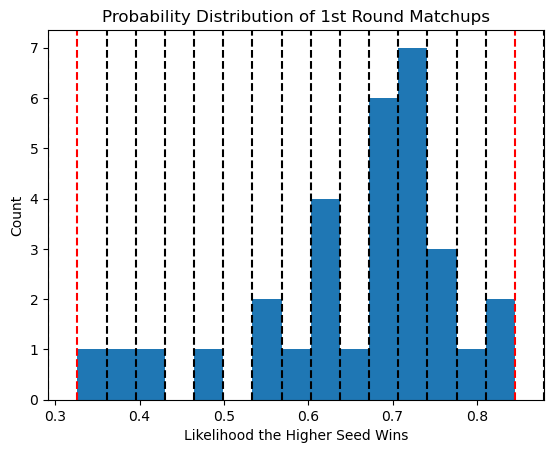

In [198]:
import matplotlib.pyplot as plt

# Plot 1: Win probability Distribution

plt.hist(yahoo["TeamA_win_prob"], bins=15)
plt.title('Probability Distribution of 1st Round Matchups')
plt.ylabel('Count')
plt.xlabel('Likelihood the Higher Seed Wins')


#print(np.min(yahoo["TeamA_win_prob"]),np.max(yahoo["TeamA_win_prob"]))
plt.axvline(x=np.min(yahoo["TeamA_win_prob"])-k, ymin=0, ymax=10,ls='--',color='black')
plt.axvline(x=np.min(yahoo["TeamA_win_prob"]), ymin=0, ymax=10,ls='--',color='red')
plt.axvline(x=np.min(yahoo["TeamA_win_prob"])+k, ymin=0, ymax=10,ls='--',color='black')
plt.axvline(x=np.min(yahoo["TeamA_win_prob"])+2*k, ymin=0, ymax=10,ls='--',color='black')
plt.axvline(x=np.min(yahoo["TeamA_win_prob"])+3*k, ymin=0, ymax=10,ls='--',color='black')
plt.axvline(x=np.min(yahoo["TeamA_win_prob"])+4*k, ymin=0, ymax=10,ls='--',color='black')
plt.axvline(x=np.min(yahoo["TeamA_win_prob"])+5*k, ymin=0, ymax=10,ls='--',color='black')
plt.axvline(x=np.min(yahoo["TeamA_win_prob"])+6*k, ymin=0, ymax=10,ls='--',color='black')
plt.axvline(x=np.min(yahoo["TeamA_win_prob"])+7*k, ymin=0, ymax=10,ls='--',color='black')
plt.axvline(x=np.min(yahoo["TeamA_win_prob"])+8*k, ymin=0, ymax=10,ls='--',color='black')
plt.axvline(x=np.min(yahoo["TeamA_win_prob"])+9*k, ymin=0, ymax=10,ls='--',color='black')
plt.axvline(x=np.min(yahoo["TeamA_win_prob"])+10*k, ymin=0, ymax=10,ls='--',color='black')
plt.axvline(x=np.min(yahoo["TeamA_win_prob"])+11*k, ymin=0, ymax=10,ls='--',color='black')
plt.axvline(x=np.min(yahoo["TeamA_win_prob"])+12*k, ymin=0, ymax=10,ls='--',color='black')
plt.axvline(x=np.min(yahoo["TeamA_win_prob"])+13*k, ymin=0, ymax=10,ls='--',color='black')
plt.axvline(x=np.min(yahoo["TeamA_win_prob"])+14*k, ymin=0, ymax=10,ls='--',color='black')
plt.axvline(x=np.min(yahoo["TeamA_win_prob"])+15*k, ymin=0, ymax=10,ls='--',color='red')
plt.axvline(x=np.min(yahoo["TeamA_win_prob"])+16*k, ymin=0, ymax=10,ls='--',color='black')

plt.xlim(np.min(yahoo["TeamA_win_prob"])-k,np.min(yahoo["TeamA_win_prob"])+16*k)

In [187]:
k = (np.max(yahoo["TeamA_win_prob"]) - np.min(yahoo["TeamA_win_prob"]))/15
print(k)

0.034611375157757154


In [186]:
print('Dashed lines are plotted at: \n')
print(np.min(yahoo["TeamA_win_prob"]))
print(np.min(yahoo["TeamA_win_prob"])+k)
print(np.min(yahoo["TeamA_win_prob"])+2*k)
print(np.min(yahoo["TeamA_win_prob"])+3*k)
print(np.min(yahoo["TeamA_win_prob"])+4*k)
print(np.min(yahoo["TeamA_win_prob"])+5*k)
print(np.min(yahoo["TeamA_win_prob"])+6*k)
print(np.min(yahoo["TeamA_win_prob"])+7*k)
print(np.min(yahoo["TeamA_win_prob"])+8*k)
print(np.min(yahoo["TeamA_win_prob"])+9*k)
print(np.min(yahoo["TeamA_win_prob"])+10*k)

Dashed lines are plotted at: 

0.3260842405418124
0.3780013032784481
0.4299183660150839
0.4818354287517196
0.5337524914883554
0.585669554224991
0.6375866169616268
0.6895036796982625
0.7414207424348982
0.793337805171534
0.8452548679081697


In [197]:
print('Plot X min:', np.min(yahoo["TeamA_win_prob"])-k)
print('Plot X max:', np.min(yahoo["TeamA_win_prob"])+16*k)

Plot X min: 0.29147286538405526
Plot X max: 0.8798662430659269


In [203]:
#print('Bar 1 spans:', round(np.min(yahoo["TeamA_win_prob"])-k,3), 'to', round(np.min(yahoo["TeamA_win_prob"]),3))
print('Bar 1 spans:', round(np.min(yahoo["TeamA_win_prob"]),3), 'to', round(np.min(yahoo["TeamA_win_prob"])+k,3))
print('Bar 2 spans:', round(np.min(yahoo["TeamA_win_prob"])+k,3), 'to', round(np.min(yahoo["TeamA_win_prob"])+2*k,3))
print('Bar 3 spans:', round(np.min(yahoo["TeamA_win_prob"])+2*k,3), 'to', round(np.min(yahoo["TeamA_win_prob"])+3*k,3))
print('Bar 4 spans:', round(np.min(yahoo["TeamA_win_prob"])+3*k,3), 'to', round(np.min(yahoo["TeamA_win_prob"])+4*k,3))
print('Bar 5 spans:', round(np.min(yahoo["TeamA_win_prob"])+4*k,3), 'to', round(np.min(yahoo["TeamA_win_prob"])+5*k,3))
print('Bar 6 spans:', round(np.min(yahoo["TeamA_win_prob"])+5*k,3), 'to', round(np.min(yahoo["TeamA_win_prob"])+6*k,3))
print('Bar 7 spans:', round(np.min(yahoo["TeamA_win_prob"])+6*k,3), 'to', round(np.min(yahoo["TeamA_win_prob"])+7*k,3))
print('Bar 8 spans:', round(np.min(yahoo["TeamA_win_prob"])+7*k,3), 'to', round(np.min(yahoo["TeamA_win_prob"])+8*k,3))

print('Bar 9 spans:', round(np.min(yahoo["TeamA_win_prob"])+8*k,3), 'to', round(np.min(yahoo["TeamA_win_prob"])+9*k,3))
print('Bar 10 spans:', round(np.min(yahoo["TeamA_win_prob"])+9*k,3), 'to', round(np.min(yahoo["TeamA_win_prob"])+10*k,3))
print('Bar 11 spans:', round(np.min(yahoo["TeamA_win_prob"])+10*k,3), 'to', round(np.min(yahoo["TeamA_win_prob"])+11*k,3))
print('Bar 12 spans:', round(np.min(yahoo["TeamA_win_prob"])+11*k,3), 'to', round(np.min(yahoo["TeamA_win_prob"])+12*k,3))
print('Bar 13 spans:', round(np.min(yahoo["TeamA_win_prob"])+12*k,3), 'to', round(np.min(yahoo["TeamA_win_prob"])+13*k,3))
print('Bar 14 spans:', round(np.min(yahoo["TeamA_win_prob"])+13*k,3), 'to', round(np.min(yahoo["TeamA_win_prob"])+14*k,3))
print('Bar 15 spans:', round(np.min(yahoo["TeamA_win_prob"])+14*k,3), 'to', round(np.min(yahoo["TeamA_win_prob"])+15*k,3))


Bar 1 spans: 0.326 to 0.361
Bar 2 spans: 0.361 to 0.395
Bar 3 spans: 0.395 to 0.43
Bar 4 spans: 0.43 to 0.465
Bar 5 spans: 0.465 to 0.499
Bar 6 spans: 0.499 to 0.534
Bar 7 spans: 0.534 to 0.568
Bar 8 spans: 0.568 to 0.603
Bar 9 spans: 0.603 to 0.638
Bar 10 spans: 0.638 to 0.672
Bar 11 spans: 0.672 to 0.707
Bar 12 spans: 0.707 to 0.741
Bar 13 spans: 0.741 to 0.776
Bar 14 spans: 0.776 to 0.811
Bar 15 spans: 0.811 to 0.845


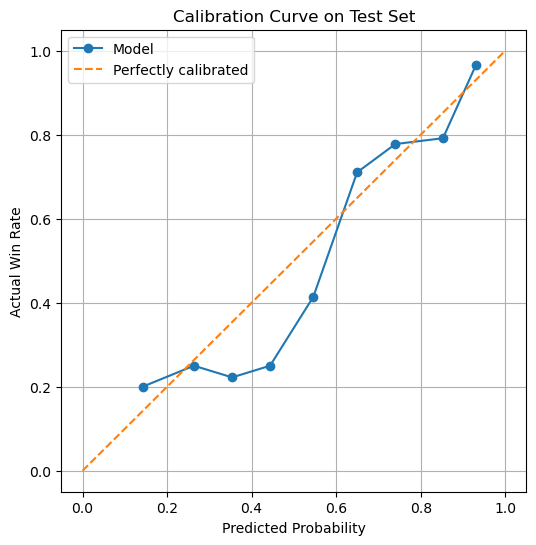

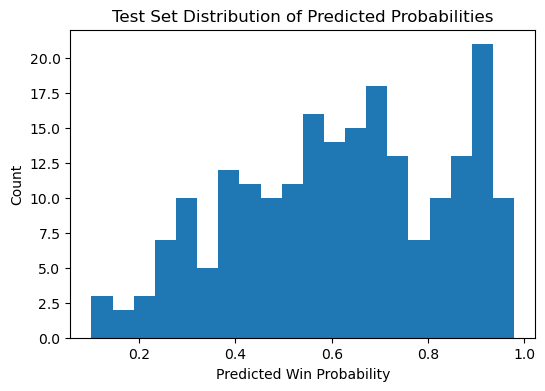

In [318]:
# Creating the Calibration Curve
from sklearn.calibration import calibration_curve

# Get predicted probabilities on TEST set
probs = model.predict_proba(X_test)[:, 1]

# Compute calibration curve
prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

# Plot
plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0,1], [0,1], linestyle='--', label='Perfectly calibrated')

plt.xlabel('Predicted Probability')
plt.ylabel('Actual Win Rate')
plt.title('Calibration Curve on Test Set')
plt.legend()
plt.grid()

plt.figure(figsize=(6,4))
plt.hist(probs, bins=20)
plt.xlabel("Predicted Win Probability")
plt.ylabel("Count")
plt.title("Test Set Distribution of Predicted Probabilities")
plt.show()

Text(0.5, 1.0, 'Understanding Feature Importance')

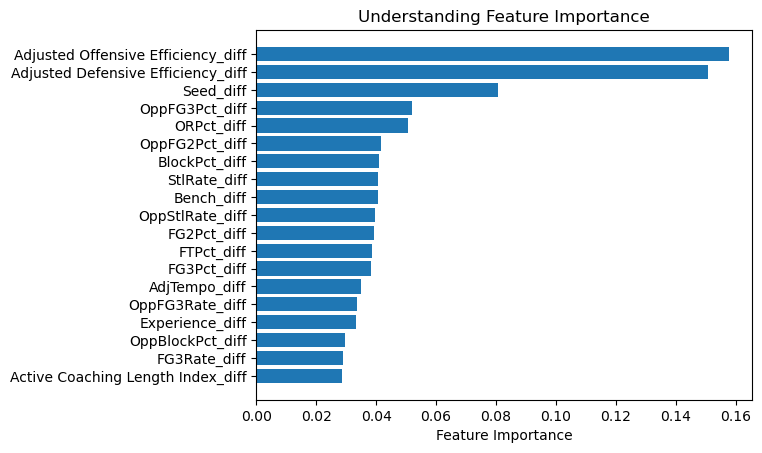

In [319]:
# Plotting Feature Importances

# Changing importances to a dataframe
imp_df = importances.reset_index().rename(columns={"index": "Features", 0: "Values"}).sort_values(by="Values", ascending=True)


# Plotting
#plt.yticks(fontsize=8,fontname='Merriweather', fontweight='bold')
plt.barh(imp_df['Features'], imp_df['Values'])
plt.xlabel('Feature Importance')
plt.title('Understanding Feature Importance')

#plt.barh(range(len(importances)),importances,tick_label=labs)




#

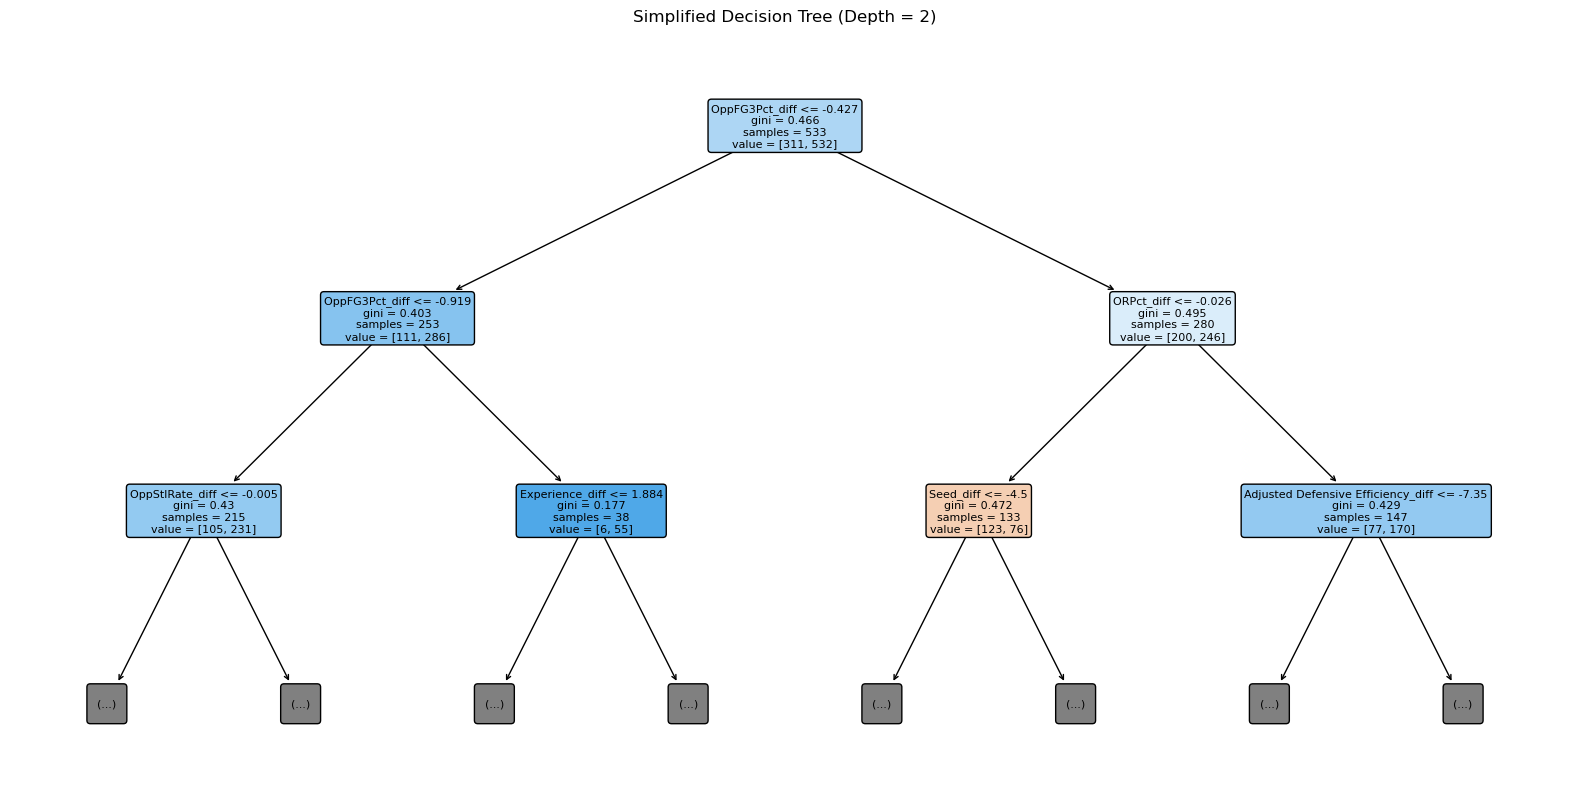

In [367]:
# Looking at a specific tree
tree = model.estimators_[0]

plt.figure(figsize=(20,10))
plot_tree(
    tree,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=2   
)
plt.title("Simplified Decision Tree (Depth = 2)")
plt.show()
